In [32]:
import os
import sys
from pathlib import Path

import IPython.display as ipd
import librosa as lr
import matplotlib.pyplot as plt
import numpy as np
import torch


In [6]:
sys.path.insert(0, str(Path.cwd().parent))

In [7]:
from train_rps_predictor import SimpleConv

In [10]:
os.listdir('../results')

['rps_high_snr_analysis.json',
 'rps_train_specific_samples',
 'rps_predictor_dccrn_2',
 'inference_comparison',
 'test_dregon_no_rps',
 'rps_predictor_dccrn',
 'rps_predictor_comparison',
 'evaluation',
 'rps_cv',
 'explore',
 'results',
 'rps_experiment_rps_only.png',
 'rps_only_results.json',
 'rps_experiment_audio_sisdr.png',
 'rps_experiment_rps_only_zoomed.png',
 'rps_eval_specific_samples',
 'rps_experiment_audio_estoi.png',
 'test_dregon_rps',
 'rps_predictor',
 'rps_predictor_dcunet',
 '.postdoc.db']

In [14]:
model = SimpleConv()
ckp = torch.load(str(get_results_path('rps_predictor/best.pt')), map_location=torch.device('cpu'))  # noqa: F821
model.load_state_dict(ckp)

<All keys matched successfully>

In [23]:
os.listdir(str(get_datasets_path('DREGON-LM-test/valid/sample_00001')))  # noqa: F821

['mixture.wav', 'vocals.wav', 'rps.npy', 'noise.wav']

In [31]:
lr.load(str(get_datasets_path('DREGON-LM-test/valid/sample_00000/mixture.wav')), sr=None)  # noqa: F821

(array([ 0.14782715,  0.12582397,  0.10281372, ..., -0.02114868,
        -0.05410767, -0.02587891], shape=(32000,), dtype=float32),
 16000)

In [77]:
def show_audio(wav: np.ndarray, sr: int, **kwargs):
    S = lr.stft(wav, **kwargs)
    S_db = lr.amplitude_to_db(np.abs(S), ref=np.max)
    res = lr.display.specshow(S_db, y_axis='hz', x_axis='time', sr=sr, **kwargs)  # noqa: F841
    display(ipd.Audio(wav, rate=sr))

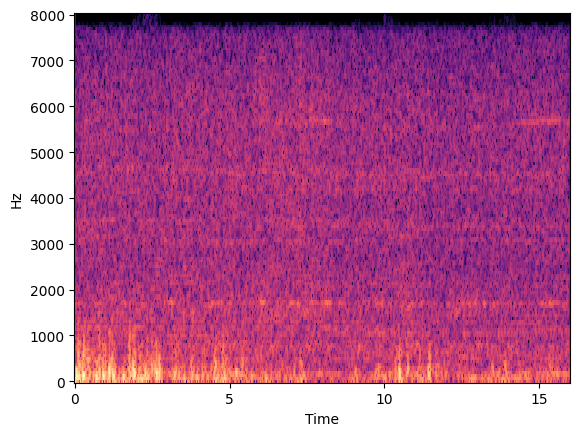

In [78]:
show_audio(*lr.load(str(get_datasets_path('DREGON-LM-test/valid/sample_00000/mixture.wav')), sr=None), n_fft=256)  # noqa: F821

In [56]:
wav, sr = lr.load(str(get_datasets_path('DREGON-LM-test/valid/sample_00000/mixture.wav')), sr=None)  # noqa: F821

In [62]:
rps = model(torch.from_numpy(wav).unsqueeze(0)).detach()

In [63]:
rps.shape

torch.Size([1, 4, 63])

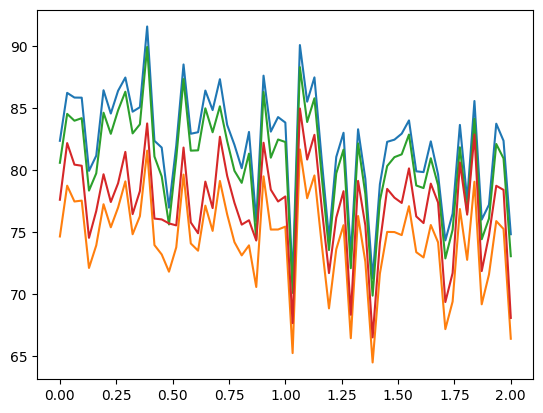

In [79]:
plt.plot(np.linspace(0, wav.shape[0] / sr, rps.shape[2]), rps.squeeze(0).numpy().T)

In [67]:
rps_gt = np.load(str(get_datasets_path('DREGON-LM-test/valid/sample_00000/rps.npy')))  # noqa: F821
rps_gt.shape

(4, 1891)

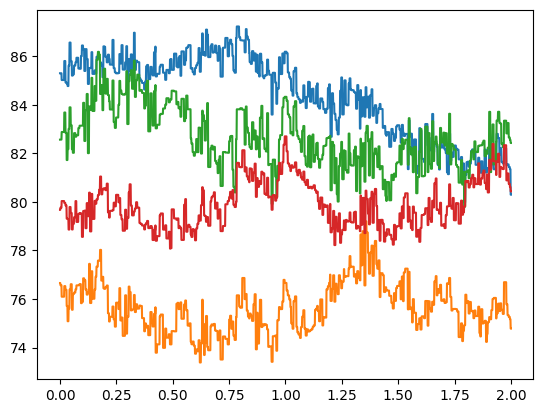

In [82]:
plt.plot(np.linspace(0, wav.shape[0] / sr, rps_gt.shape[1]), rps_gt.T)